# Red Neuronal para Clasificación de ECG (Normal / Anómalo)
### Versión Google Colab — Taller PyCon

Se creará una red neuronal (Teacher) que clasifique latidos cardíacos como Normales o Anómalos, para su posterior compresión y despliegue en FPGA.

**Dataset:** PTB Diagnostic ECG Database (vía Kaggle) — 187 puntos por latido, ya normalizado en [0,1].

Flujo de trabajo basado en:
R. S. Molina et al., *An End-to-End Workflow to Efficiently Compress and Deploy DNN Classifiers on SoC/FPGA*, IEEE Embedded Systems Letters, vol. 16, no. 3, 2024.

**Nota:** este notebook es independiente de P0 — cada notebook de Colab corre en su propia VM, así que aquí se vuelve a descargar y preparar el dataset (versión condensada, sin las gráficas exploratorias que ya viste en P0).

### Instalación de librerías (específico de Colab)

`qkeras` y `tensorflow-model-optimization` no vienen preinstaladas. **Importante:** QKeras puede requerir fijar la versión de TensorFlow — si ves errores de compatibilidad al importar, avisa para ajustar versiones antes del taller.

In [1]:
!pip install -q qkeras tensorflow-model-optimization gdown

# Si tu repo ya existe, reemplaza este bloque por:
# !git clone https://github.com/tu-usuario/taller-ecg-fpga.git
# %cd taller-ecg-fpga
#
# y asegurate de que src/distillationClassKeras.py este disponible ahi.
# Por ahora, mientras pruebas localmente, se descargan estos archivos auxiliares
# directamente (ajusta la URL si los alojas en tu propio repo).

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.8/152.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.6 MB/s eta 0:00:00


### Preparación de datos (versión condensada de P0)

Mismo patrón de P0: `USE_DRIVE = True` (Google Drive + FILE_ID) o `False` (subida manual del .zip). Por defecto queda en carga manual.


In [2]:
USE_DRIVE = False   # True = Google Drive (gdown) | False = carga manual

FILE_ID = 'REEMPLAZAR_CON_TU_FILE_ID'   # solo si USE_DRIVE = True

import zipfile
from pathlib import Path
import pandas as pd
import numpy as np
import shutil

if USE_DRIVE:
    import gdown
    gdown.download(id=FILE_ID, output='ptbdb_ecg.zip', quiet=False)
else:
    from google.colab import files
    print('Sube tu archivo ptbdb_ecg.zip:')
    uploaded = files.upload()
    assert len(uploaded) > 0, 'No subiste ningun archivo'
    uploaded_name = list(uploaded.keys())[0]
    shutil.move(uploaded_name, 'ptbdb_ecg.zip')
    print(f"Archivo '{uploaded_name}' guardado como 'ptbdb_ecg.zip'")

data_dir = Path('dataset')
data_dir.mkdir(exist_ok=True)
with zipfile.ZipFile('ptbdb_ecg.zip', 'r') as z:
    z.extractall(data_dir)

LABEL_COL = 187
raw_normal   = pd.read_csv(data_dir / 'ptbdb_normal.csv',   header=None)
raw_abnormal = pd.read_csv(data_dir / 'ptbdb_abnormal.csv', header=None)

normal_vect   = raw_normal.iloc[:,   :LABEL_COL].values.astype(np.float32)
abnormal_vect = raw_abnormal.iloc[:, :LABEL_COL].values.astype(np.float32)

df_normal_full   = pd.DataFrame(normal_vect);   df_normal_full["class"]   = 0
df_abnormal_full = pd.DataFrame(abnormal_vect); df_abnormal_full["class"] = 1

n_samples = min(1000, len(df_normal_full), len(df_abnormal_full))
test_normal   = df_normal_full.sample(n=n_samples, random_state=45)
test_abnormal = df_abnormal_full.sample(n=n_samples, random_state=45)
train_normal   = df_normal_full.drop(test_normal.index)
train_abnormal = df_abnormal_full.drop(test_abnormal.index)

test_df  = pd.concat([test_normal, test_abnormal]).sample(frac=1, random_state=42).reset_index(drop=True)
train_df = pd.concat([train_normal, train_abnormal]).sample(frac=1, random_state=42).reset_index(drop=True)

test_df.to_csv("dataset/test_dataset.csv",   index=False)
train_df.to_csv("dataset/train_dataset.csv", index=False)

print(f"train_df: {train_df.shape}  |  test_df: {test_df.shape}")


Sube tu archivo ptbdb_ecg.zip:


Saving ptbdb_ecg.zip to ptbdb_ecg.zip
Archivo 'ptbdb_ecg.zip' guardado como 'ptbdb_ecg.zip'
train_df: (12552, 188)  |  test_df: (2000, 188)


### Librerías (pipeline ML)

In [3]:
import os
import numpy as np
from numpy import array
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd

# Tensorflow and Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.regularizers import l2, l1

import tensorflow_model_optimization as tfmot

# Pruning API
from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_schedule, pruning_callbacks
from tensorflow_model_optimization.sparsity.keras import strip_pruning

# Quantization API
from qkeras import *

# Knowledge Distillation
# from src.distillationClassKeras import *   # descomentar cuando tengas el repo clonado

# Metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle

# Pre-processing
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

# Training utils
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
np.random.seed(42)

### Funciones auxiliares

Definición de funciones auxiliares para el preprocesamiento del dataset y separación del set de datos en entrenamiento y test.

**Cambio vs. EJ-299-33:** se quitó la normalización `/512.0` — el dataset PTB ya viene normalizado en [0,1] desde Kaggle. **No la vuelvas a aplicar**, o vas a aplastar la señal a valores cercanos a 0.

In [4]:
# Function to define the training and testing datasets

def preproc_dataset(signal_dfAbnormal, signal_dfNormal,
                    train_size=2000,
                    test_size=500,
                    seed=42):

    LABEL = "class"

    # shuffle reproducible
    signal_dfAbnormal = shuffle(signal_dfAbnormal, random_state=seed)
    signal_dfNormal   = shuffle(signal_dfNormal,   random_state=seed)

    # Ajustar train_size al maximo disponible en ambas clases
    # (con PTB, Normal es la clase limitante: ~3046 tras el split de P0)
    max_available = min(len(signal_dfAbnormal), len(signal_dfNormal)) - test_size
    if train_size > max_available:
        print(f"Ajustando train_size de {train_size} a {max_available} (maximo disponible)")
        train_size = max_available

    # seleccionar tamaños iguales
    train_abnormal = signal_dfAbnormal.iloc[:train_size]
    test_abnormal  = signal_dfAbnormal.iloc[train_size:train_size+test_size]

    train_normal = signal_dfNormal.iloc[:train_size]
    test_normal  = signal_dfNormal.iloc[train_size:train_size+test_size]

    # combinar
    dfTrain = pd.concat([train_abnormal, train_normal])
    dfTest  = pd.concat([test_abnormal,  test_normal])

    # mezclar final
    dfTrain = shuffle(dfTrain, random_state=seed).reset_index(drop=True)
    dfTest  = shuffle(dfTest,  random_state=seed).reset_index(drop=True)

    # ---------- NORMALIZACION ----------
    # PTB ya viene en [0,1] desde Kaggle -> NO se re-normaliza aqui
    # (a diferencia de EJ-299-33, que dividia entre 512.0)

    return dfTrain, dfTest

## Dataset

Aquí se carga y se construye el dataset (los CSVs generados en la celda de preparación de datos, arriba).

In [5]:
# Define paths
PATH = "dataset/"

TRAIN_DATASET_FILE = PATH + "train_dataset.csv"
TEST_DATASET_FILE  = PATH + "test_dataset.csv"

# Load datasets
dfTrain = pd.read_csv(TRAIN_DATASET_FILE)
dfTestPTB = pd.read_csv(TEST_DATASET_FILE)

# Separate classes (convencion PTB: 0=normal, 1=anomalo)
dfNormal   = dfTrain[dfTrain["class"] == 0]
dfAbnormal = dfTrain[dfTrain["class"] == 1]

print(f"Train Normal  : {len(dfNormal)} muestras")
print(f"Train Anomalo : {len(dfAbnormal)} muestras")

Train Normal  : 3046 muestras
Train Anomalo : 9506 muestras


### Preprocesamiento y separación de dataset

In [6]:
# Pre-processing dataset for training
df_train, dfTest = preproc_dataset(dfAbnormal, dfNormal)

df_train_ = df_train.pop('class')
dfTest_   = dfTest.pop('class')

# One-hot encoder
le = LabelEncoder()
y = le.fit_transform(df_train_)
y = to_categorical(y, 2)

le = LabelEncoder()
yTest = le.fit_transform(dfTest_)
yTest = to_categorical(yTest, 2)

# Split training dataset into training and validation
x_train, x_val, y_train, y_val = train_test_split(df_train, y, test_size=0.3, random_state=42)

x_train = x_train.astype(np.float32)
x_val   = x_val.astype(np.float32)

print(f"x_train: {x_train.shape} | x_val: {x_val.shape} | dfTest: {dfTest.shape}")

x_train: (2800, 187) | x_val: (1200, 187) | dfTest: (1000, 187)


## Machine learning - Training and compression

**Poda (Pruning)**: reduce el tamaño y complejidad del modelo eliminando pesos poco relevantes.

**Quantization Aware Training (QAT)**: simula la cuantización durante el entrenamiento para adaptar el modelo a la pérdida de precisión numérica en FPGA.

**Knowledge Distillation**: un modelo pequeño (estudiante) aprende de uno grande (maestro) a través de sus predicciones suaves.

## Entrenamiento del Teacher

In [7]:
# Define the hyperparameters for the teacher model
# Arquitectura reutilizada de EJ-299-33 (161->187 solo cambia el input, no la topologia)

lr = 0.0001
neurons_teacher = [10, 5, 7, 5, 6]

La siguiente función define la arquitectura del **teacher** compuesto por seis capas densas. **Cambio vs. EJ-299-33:** el input pasa de 161 a **187** puntos (el largo fijo de cada latido en PTB); la salida sigue siendo binaria (`Dense(2)`), sin cambios ahí.

In [8]:
N_INPUT = 187   # EJ-299-33 usaba 161

def teacher_topology(bestHp):

    teacher = keras.Sequential(
        [
            keras.Input(shape=(N_INPUT, )),
            Dense(bestHp[0], name='fc1', input_shape=(N_INPUT,), kernel_regularizer=l2(0.001),),
            Activation(activation='relu', name='relu1'),

            Dense(bestHp[1], name='fc2', kernel_regularizer=l2(0.001),),
            Activation(activation='relu', name='relu2'),

            Dense(bestHp[2], name='fc3', kernel_regularizer=l2(0.001),),
            Activation(activation='relu', name='relu3'),
            Dropout(0.1),

            Dense(bestHp[3], name='fc4', kernel_regularizer=l2(0.001),),
            Activation(activation='relu', name='relu4'),
            Dropout(0.2),

            Dense(bestHp[4], name='fc5'),
            Activation(activation='relu', name='relu5'),
            Dropout(0.2),

            Dense(2, name='output'),
            Activation('softmax', name='activationOutput'),
        ],
        name='teacher_MLP',
    )

    teacher.summary()

    return teacher

### Construcción del modelo Teacher

Sin cambios respecto al original: arquitectura definida en `teacher_topology()`, optimizador **Adam**, pérdida `binary_crossentropy`.

In [9]:
def build_teacher(neurons_teacher):
    model = teacher_topology(neurons_teacher)
    opt = Adam(lr)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [10]:
teacher_model = build_teacher(neurons_teacher)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "teacher_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc1 (Dense)                     │ (None, 10)             │         1,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 7)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc4 (Dense)                     │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (Activation)              │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc5 (Dense)                     │ (None, 6)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu5 (Activation)              │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │            14 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activationOutput (Activation)   │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,067 (8.07 KB)

 Trainable params: 2,067 (8.07 KB)

 Non-trainable params: 0 (0.00 B)

## Training

Entrenamiento del modelo teacher. Con ~2,000-3,000 muestras por clase y esta arquitectura pequeña, debería converger en pocos minutos incluso en la CPU/GPU gratuita de Colab.

In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=2,
        verbose=1,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.4,
        patience=3,
        verbose=1
    )
]

history_teacher = teacher_model.fit(
    x=x_train, y=y_train,
    validation_data=(x_val, y_val),
    batch_size=64,
    epochs=200,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4696 - loss: 0.7322 - val_accuracy: 0.4542 - val_loss: 0.7295 - learning_rate: 1.0000e-04
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4843 - loss: 0.7291 - val_accuracy: 0.4850 - val_loss: 0.7277 - learning_rate: 1.0000e-04
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4921 - loss: 0.7273 - val_accuracy: 0.4867 - val_loss: 0.7264 - learning_rate: 1.0000e-04
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4986 - loss: 0.7261 - val_accuracy: 0.4867 - val_loss: 0.7253 - learning_rate: 1.0000e-04
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4936 - loss: 0.7249 - val_accuracy: 0.4867 - val_loss: 0.7241 - learning_rate: 1.0000e-04
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5125 - loss: 0.7237 - val_accuracy: 0.4867 - val_loss: 0.7230 - learning_rate: 1.0000e-04
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5436

### Plot accuracy and loss

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


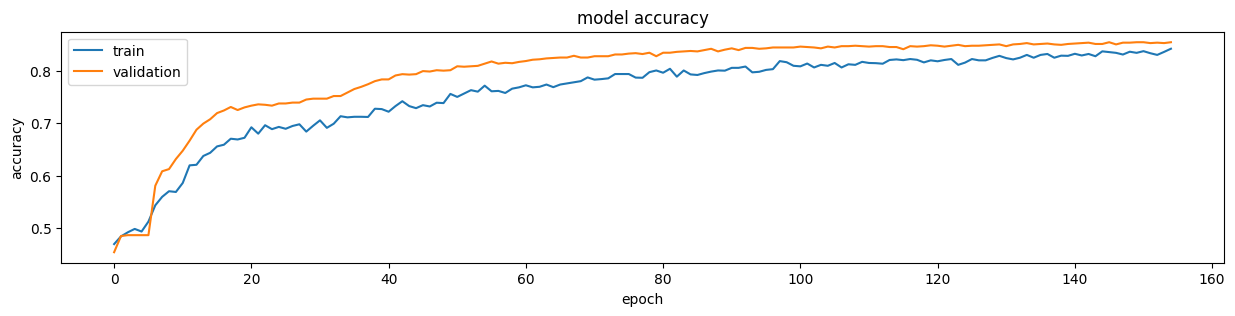

<Figure size 640x480 with 0 Axes>

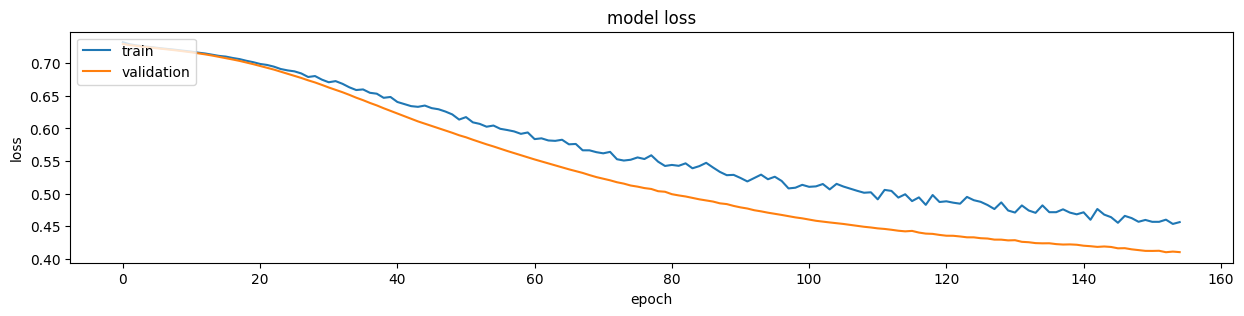

In [12]:
print(history_teacher.history.keys())

## Plot for accuracy
plt.figure(figsize=(15,3))
plt.plot(history_teacher.history['accuracy'])
plt.plot(history_teacher.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()
plt.figure()

## Plot for loss
plt.figure(figsize=(15,3))
plt.plot(history_teacher.history['loss'])
plt.plot(history_teacher.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Hasta aquí ya se logró un entrenamiento satisfactorio de la red neuronal

---
---

## Análisis del rendimiento

Medimos el rendimiento mediante la matriz de confusión

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


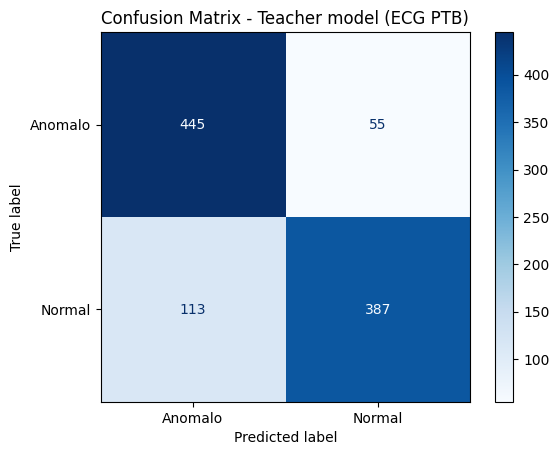

In [13]:
# Obtain the confusion matrix using the testing dataset
y_pred_probs = teacher_model.predict(dfTest)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = np.argmax(yTest, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Anomalo', 'Normal'])
disp.plot(cmap="Blues")
plt.title('Confusion Matrix - Teacher model (ECG PTB)')
plt.show()

### Guardado del modelo Teacher

**Importante en Colab:** este archivo vive solo en la VM temporal. Si no lo descargas o lo mueves a Drive/repo antes de cerrar la sesión, se pierde.

In [14]:
os.makedirs('models', exist_ok=True)
teacher_model.save('models/teacherModel_ECG_PTB.h5')

# Descargar el modelo a tu computador (opcional, util mientras pruebas)
from google.colab import files
files.download('models/teacherModel_ECG_PTB.h5')

# Alternativa: guardarlo directamente en Drive si lo montaste
# teacher_model.save('/content/drive/MyDrive/taller-ecg-fpga/models/teacherModel_ECG_PTB.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
**Siguiente paso:** P2 — Pruning + QAT sobre este Teacher, para construir el Student.